# Exploratory Analysis: Biodiversity Loss and UK Beef Imports

**Research question:** Is biodiversity loss in beef-exporting countries associated with the volume of beef exports to the United Kingdom?

This notebook walks through every analytical choice with full transparency. Each decision is shown and justified inline—the notebook *is* the argument.

---


## 1) Raw Data Inspection

We start by printing shapes, columns, date ranges, and sample rows from each source so the reader can see exactly what we're working with.


In [106]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')

DATA = os.path.dirname(os.path.abspath('__file__'))
BIO_PATH = os.path.join(DATA, 'bio-raw.csv')
FAO_PATH = os.path.join(DATA, 'FAOSTAT_data_en_3-31-2026.csv')
CLEAN = os.path.join(DATA, 'clean')
FIGURES = os.path.join(DATA, 'figures')
os.makedirs(FIGURES, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 1a. BIO raw data
# ─────────────────────────────────────────────────────────────────────────────
bio_raw = pd.read_csv(BIO_PATH, low_memory=False)
print('=' * 70)
print('BIO RAW DATA')
print('=' * 70)
print(f'Shape: {bio_raw.shape}')
print(f'Columns: {list(bio_raw.columns)}')
print(f'Year range: {bio_raw["year"].min()} – {bio_raw["year"].max()}')
print(f'Scenarios: {bio_raw["scenario"].nunique()} unique')
print(f'Variables (indicators): {bio_raw["variable"].unique().tolist()}')
print('\nSample rows:')
display(bio_raw.head(5))

# ─────────────────────────────────────────────────────────────────────────────
# 1b. FAOSTAT raw data
# ─────────────────────────────────────────────────────────────────────────────
fao_raw = pd.read_csv(FAO_PATH, encoding='utf-8-sig')
print('\n' + '=' * 70)
print('FAOSTAT RAW DATA')
print('=' * 70)
print(f'Shape: {fao_raw.shape}')
print(f'Columns: {list(fao_raw.columns)}')
print(f'Year range: {fao_raw["Year"].min()} – {fao_raw["Year"].max()}')
print(f'Partner (importer): {fao_raw["Partner Countries"].unique().tolist()}')
print(f'Items: {fao_raw["Item"].unique().tolist()}')
print(f'Reporter countries (exporters): {fao_raw["Reporter Countries"].nunique()}')
print('\nSample rows:')
display(fao_raw.head(5))


BIO RAW DATA
Shape: (376992, 8)
Columns: ['_id', 'area_code', 'lower_uncertainty', 'scenario', 'upper_uncertainty', 'value', 'variable', 'year']
Year range: 1970 – 2050
Scenarios: 6 unique
Variables (indicators): ['bii', 'crops', 'highintensityag', 'hpd', 'pastureland', 'qualitynatural', 'urbanextent']

Sample rows:


,_id,area_code,lower_uncertainty,scenario,upper_uncertainty,value,variable,year
0,344002,001-002-202-018-BWA,NaN,ssp4rcp6p0gcam,NaN,0.759763,bii,2044
1,344003,001-002-202-018-LSO,NaN,ssp4rcp6p0gcam,NaN,0.553173,bii,2044
2,344006,001-002-202-018-ZAF,NaN,ssp4rcp6p0gcam,NaN,0.623727,bii,2044
3,344014,001-009-054-PNG,NaN,ssp4rcp6p0gcam,NaN,0.986023,bii,2044
4,344023,001-009-057-PLW,NaN,ssp4rcp6p0gcam,NaN,NaN,bii,2044



FAOSTAT RAW DATA
Shape: (763, 16)
Columns: ['Domain Code', 'Domain', 'Reporter Country Code (M49)', 'Reporter Countries', 'Partner Country Code (M49)', 'Partner Countries', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description']
Year range: 2001 – 2024
Partner (importer): ['United Kingdom of Great Britain and Northern Ireland']
Items: ['Beef and veal preparations nes']
Reporter countries (exporters): 67

Sample rows:


,Domain Code,Domain,Reporter Country Code (M49),Reporter Countries,Partner Country Code (M49),Partner Countries,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description
0,TM,Detailed trade matrix,32,Argentina,826,United Kingdom of Great Britain and Northern I...,5910,Export quantity,F0875,Beef and veal preparations nes,2001,2001,t,5652.0,A,Official figure
1,TM,Detailed trade matrix,32,Argentina,826,United Kingdom of Great Britain and Northern I...,5910,Export quantity,F0875,Beef and veal preparations nes,2002,2002,t,6247.0,A,Official figure
2,TM,Detailed trade matrix,32,Argentina,826,United Kingdom of Great Britain and Northern I...,5910,Export quantity,F0875,Beef and veal preparations nes,2003,2003,t,6065.0,A,Official figure
3,TM,Detailed trade matrix,32,Argentina,826,United Kingdom of Great Britain and Northern I...,5910,Export quantity,F0875,Beef and veal preparations nes,2004,2004,t,9796.0,A,Official figure
4,TM,Detailed trade matrix,32,Argentina,826,United Kingdom of Great Britain and Northern I...,5910,Export quantity,F0875,Beef and veal preparations nes,2005,2005,t,6830.0,A,Official figure


## 2) Country Name Harmonisation

Cross-dataset joins require a common identifier. Country names differ across sources—we demonstrate the mismatch problem, build a mapping to ISO-3 codes, and report merge success/failure rates.


In [107]:
# ─────────────────────────────────────────────────────────────────────────────
# 2a. Show the mismatch problem
# ─────────────────────────────────────────────────────────────────────────────
bio_area_codes = bio_raw['area_code'].dropna().str.split('-').str[-1].str.upper().unique()
fao_names = fao_raw['Reporter Countries'].unique()

print('BIO dataset uses area_code with ISO3 as the final segment:')
print(f'  Sample area_codes: {bio_raw["area_code"].dropna().unique()[:5].tolist()}')
print(f'  Extracted ISO3 codes (sample): {list(bio_area_codes[:10])}')

print('\nFAOSTAT uses full country names:')
print(f'  Sample names: {list(fao_names[:10])}')

# Examples of names that don't align:
problem_names = [
    'China, mainland',
    'Netherlands (Kingdom of the)',
    'Trkiye',
    'Republic of Korea',
    'Viet Nam',
]
print('\nExamples of FAOSTAT names that need manual mapping:')
for n in problem_names:
    if n in fao_names:
        print(f'  - "{n}"')


BIO dataset uses area_code with ISO3 as the final segment:
  Sample area_codes: ['001-002-202-018-BWA', '001-002-202-018-LSO', '001-002-202-018-ZAF', '001-009-054-PNG', '001-009-057-PLW']
  Extracted ISO3 codes (sample): ['BWA', 'LSO', 'ZAF', 'PNG', 'PLW', 'COK', 'NIU', 'PYF', 'COL', 'ECU']

FAOSTAT uses full country names:
  Sample names: ['Argentina', 'Australia', 'Austria', 'Bahamas', 'Bahrain', 'Belgium', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria']

Examples of FAOSTAT names that need manual mapping:
  - "China, mainland"
  - "Netherlands (Kingdom of the)"
  - "Republic of Korea"
  - "Viet Nam"


In [108]:
# ─────────────────────────────────────────────────────────────────────────────
# 2b. Build and display the mapping dictionary
# ─────────────────────────────────────────────────────────────────────────────
FAOSTAT_ISO3 = {
    "Argentina":                    "ARG",
    "Australia":                    "AUS",
    "Austria":                      "AUT",
    "Bahrain":                      "BHR",
    "Belgium":                      "BEL",
    "Botswana":                     "BWA",
    "Brazil":                       "BRA",
    "Brunei Darussalam":            "BRN",
    "Bulgaria":                     "BGR",
    "China, mainland":              "CHN",
    "China, Taiwan Province of":    "TWN",
    "Colombia":                     "COL",
    "Croatia":                      "HRV",
    "Cyprus":                       "CYP",
    "Czechia":                      "CZE",
    "Denmark":                      "DNK",
    "Dominican Republic":           "DOM",
    "Estonia":                      "EST",
    "Finland":                      "FIN",
    "France":                       "FRA",
    "Germany":                      "DEU",
    "Ghana":                        "GHA",
    "Greece":                       "GRC",
    "Hungary":                      "HUN",
    "Iceland":                      "ISL",
    "India":                        "IND",
    "Indonesia":                    "IDN",
    "Ireland":                      "IRL",
    "Israel":                       "ISR",
    "Italy":                        "ITA",
    "Jamaica":                      "JAM",
    "Kyrgyzstan":                   "KGZ",
    "Latvia":                       "LVA",
    "Lebanon":                      "LBN",
    "Lithuania":                    "LTU",
    "Luxembourg":                   "LUX",
    "Malta":                        "MLT",
    "Mozambique":                   "MOZ",
    "Namibia":                      "NAM",
    "Netherlands (Kingdom of the)": "NLD",
    "New Zealand":                  "NZL",
    "Norway":                       "NOR",
    "Philippines":                  "PHL",
    "Poland":                       "POL",
    "Portugal":                     "PRT",
    "Republic of Korea":            "KOR",
    "Romania":                      "ROU",
    "Russian Federation":           "RUS",
    "Singapore":                    "SGP",
    "Slovakia":                     "SVK",
    "Slovenia":                     "SVN",
    "South Africa":                 "ZAF",
    "Spain":                        "ESP",
    "Sweden":                       "SWE",
    "Switzerland":                  "CHE",
    "Trinidad and Tobago":          "TTO",
    "Trkiye":                       "TUR",
    "Türkiye":                      "TUR",
    "Ukraine":                      "UKR",
    "United Arab Emirates":         "ARE",
    "United States of America":     "USA",
    "Uruguay":                      "URY",
    "Viet Nam":                     "VNM",
    "Zimbabwe":                     "ZWE",
}

print(f'Mapping dictionary covers {len(FAOSTAT_ISO3)} FAOSTAT country names.')
print('\nSample mappings:')
for i, (k, v) in enumerate(FAOSTAT_ISO3.items()):
    if i >= 10:
        print('  ...')
        break
    print(f'  "{k}" -> {v}')


Mapping dictionary covers 64 FAOSTAT country names.

Sample mappings:
  "Argentina" -> ARG
  "Australia" -> AUS
  "Austria" -> AUT
  "Bahrain" -> BHR
  "Belgium" -> BEL
  "Botswana" -> BWA
  "Brazil" -> BRA
  "Brunei Darussalam" -> BRN
  "Bulgaria" -> BGR
  "China, mainland" -> CHN
  ...


In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# 2c. Apply mapping to FAOSTAT and report merge success
# ─────────────────────────────────────────────────────────────────────────────
IMPORT_COUNTRY = "United Kingdom of Great Britain and Northern Ireland"
fao = fao_raw[fao_raw['Partner Countries'] == IMPORT_COUNTRY].copy()
fao['iso3'] = fao['Reporter Countries'].map(FAOSTAT_ISO3)

mapped = fao[fao['iso3'].notna()]
unmapped = fao[fao['iso3'].isna()]

print(f'FAOSTAT rows after filtering to UK imports: {len(fao)}')
print(f'  Successfully mapped to ISO3: {len(mapped)} rows ({len(mapped)/len(fao)*100:.1f}%)')
print(f'  Failed to map (dropped):     {len(unmapped)} rows ({len(unmapped)/len(fao)*100:.1f}%)')

if len(unmapped) > 0:
    print(f'\nUnmapped country names:')
    for n in unmapped['Reporter Countries'].unique():
        print(f'  - "{n}"')
else:
    print('\nAll FAOSTAT country names successfully mapped. ✓')

fao = mapped.copy()
print(f'\nUnique exporting countries (ISO3): {fao["iso3"].nunique()}')


FAOSTAT rows after filtering to UK imports: 763
  Successfully mapped to ISO3: 759 rows (99.5%)
  Failed to map (dropped):     4 rows (0.5%)

Unmapped country names:
  - "Bahamas"
  - "Cambodia"
  - "Canada"
  - "Chile"

Unique exporting countries (ISO3): 63


In [110]:
# ─────────────────────────────────────────────────────────────────────────────
# 2d. Apply ISO3 extraction to BIO and report coverage
# ─────────────────────────────────────────────────────────────────────────────
bio = bio_raw.dropna(subset=['area_code']).copy()
bio['iso3'] = bio['area_code'].str.split('-').str[-1].str.upper()
bio = bio[bio['iso3'].str.match(r'^[A-Z]{3}$', na=False)]

print(f'BIO rows with valid ISO3: {len(bio):,} ({len(bio)/len(bio_raw)*100:.1f}% of raw)')
print(f'Unique countries in BIO: {bio["iso3"].nunique()}')

# Check overlap
bio_countries = set(bio['iso3'].unique())
fao_countries = set(fao['iso3'].unique())
overlap = bio_countries & fao_countries

print(f'\nCountry overlap between BIO and FAO:')
print(f'  BIO countries:  {len(bio_countries)}')
print(f'  FAO countries:  {len(fao_countries)}')
print(f'  Intersection:   {len(overlap)}')
print(f'  FAO-only (no BIO data): {fao_countries - bio_countries}')


BIO rows with valid ISO3: 332,640 (88.2% of raw)
Unique countries in BIO: 240

Country overlap between BIO and FAO:
  BIO countries:  240
  FAO countries:  63
  Intersection:   62
  FAO-only (no BIO data): {'TWN'}


## 3) Variable Construction

### 3.1 `bii_loss = 1 - BII`
The raw BII ranges 0–1 where 1 = fully intact. We flip it so that **higher values = more biodiversity loss**, making the predictor coefficient more intuitive (positive = more loss → more exports).

### 3.2 `log_uk_import_qty_t = log(1 + qty)`
Trade volumes are heavily right-skewed. Log transformation reduces the influence of dominant exporters and yields a more normal distribution suitable for OLS.

### 3.3 Minimum trade threshold
Countries with negligible total exports (< 10 tonnes across all years) are dropped to focus on economically meaningful trade relationships.


In [111]:
# ─────────────────────────────────────────────────────────────────────────────
# 3a. Create bii_loss and filter to BII indicator only
# ─────────────────────────────────────────────────────────────────────────────
bio = bio[bio['variable'] == 'bii'].copy()
bio.rename(columns={'value': 'bii'}, inplace=True)
bio['bii_loss'] = 1 - bio['bii']

print(f'BII indicator rows: {len(bio):,}')
print(f'bii_loss range: {bio["bii_loss"].min():.4f} – {bio["bii_loss"].max():.4f}')
print(f'\nRationale: bii_loss = 1 - BII so that higher values indicate more biodiversity degradation.')


BII indicator rows: 47,520
bii_loss range: 0.0000 – 0.7066

Rationale: bii_loss = 1 - BII so that higher values indicate more biodiversity degradation.


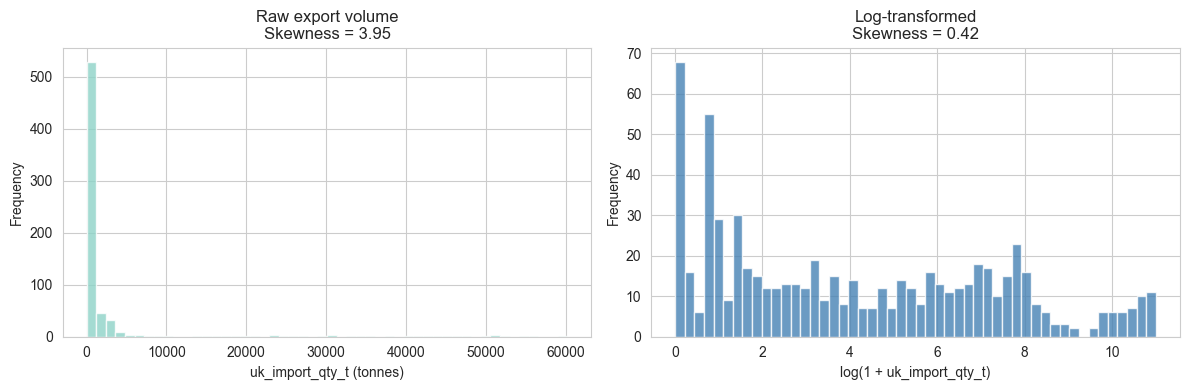

Log transformation dramatically reduces right-skew, making OLS assumptions more tenable.


In [112]:
# ─────────────────────────────────────────────────────────────────────────────
# 3b. Create log_uk_import_qty_t with before/after histogram
# ─────────────────────────────────────────────────────────────────────────────
fao = fao.rename(columns={'Value': 'uk_import_qty_t', 'Year': 'year', 'Reporter Countries': 'country'})
fao = fao[fao['uk_import_qty_t'] > 0].copy()
fao['log_uk_import_qty_t'] = np.log1p(fao['uk_import_qty_t'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fao['uk_import_qty_t'], bins=50, edgecolor='white', alpha=0.8)
axes[0].set_xlabel('uk_import_qty_t (tonnes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Raw export volume\nSkewness = {fao["uk_import_qty_t"].skew():.2f}')

axes[1].hist(fao['log_uk_import_qty_t'], bins=50, edgecolor='white', alpha=0.8, color='steelblue')
axes[1].set_xlabel('log(1 + uk_import_qty_t)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Log-transformed\nSkewness = {fao["log_uk_import_qty_t"].skew():.2f}')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'log_transform_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Log transformation dramatically reduces right-skew, making OLS assumptions more tenable.')


In [113]:
# ─────────────────────────────────────────────────────────────────────────────
# 3c. Apply 10-tonne minimum threshold
# ─────────────────────────────────────────────────────────────────────────────
MIN_TOTAL_TRADE_T = 10

total_by_country = fao.groupby('iso3')['uk_import_qty_t'].sum()
keep_countries = total_by_country[total_by_country >= MIN_TOTAL_TRADE_T].index
dropped_countries = set(fao['iso3'].unique()) - set(keep_countries)

print(f'Total trade by country (sample):')
display(total_by_country.sort_values(ascending=False).head(10))

print(f'\nMinimum threshold: {MIN_TOTAL_TRADE_T} tonnes')
print(f'Countries dropped (< {MIN_TOTAL_TRADE_T}t total): {len(dropped_countries)}')
if dropped_countries:
    print(f'  {dropped_countries}')

fao = fao[fao['iso3'].isin(keep_countries)].copy()
print(f'\nRemaining sample: {len(fao)} rows, {fao["iso3"].nunique()} countries')


Total trade by country (sample):


iso3
BRA    867900.18
IRL    863080.69
ARG     68284.10
DNK     57467.02
FRA     50332.97
URY     36874.08
NLD     32935.81
DEU     27875.95
BEL     23682.11
POL     22961.83
Name: uk_import_qty_t, dtype: float64


Minimum threshold: 10 tonnes
Countries dropped (< 10t total): 22
  {'IND', 'ISR', 'JAM', 'DOM', 'BHR', 'GHA', 'FIN', 'PHL', 'RUS', 'LUX', 'MOZ', 'LBN', 'VNM', 'CYP', 'SGP', 'CHE', 'MLT', 'KGZ', 'TTO', 'TUR', 'CHN', 'KOR'}

Remaining sample: 608 rows, 36 countries


## 4) Merged Panel Construction

We inner-join BIO and FAO on `(iso3, year)`. The key constraint is that historical BIO data ends in 2014, while FAO data covers 2010–2020. The overlap determines our analysis windows:

- **Primary panel (2010–2014):** Both datasets fully observed.
- **Extended panel (2010–2020):** Uses SSP2 projections for BIO 2015–2020.

We flag which observations rely on observed vs projected BII.


In [114]:
# ─────────────────────────────────────────────────────────────────────────────
# 4a. Prepare BIO slices
# ─────────────────────────────────────────────────────────────────────────────
EXTENSION_SCENARIO = 'ssp2rcp4p5messageglobiom'

bio_hist = bio[bio['scenario'] == 'historical'].copy()
bio_ssp2 = bio[(bio['scenario'] == EXTENSION_SCENARIO) & (bio['year'].between(2015, 2020))].copy()

print(f'Historical BIO: {len(bio_hist):,} rows, years {bio_hist["year"].min()}–{bio_hist["year"].max()}')
print(f'SSP2 projected BIO (2015-2020): {len(bio_ssp2):,} rows')

# Combined for extended panel
bio_combined = pd.concat([
    bio_hist[bio_hist['year'].between(2010, 2014)],
    bio_ssp2,
], ignore_index=True)
bio_combined['bio_source'] = np.where(bio_combined['year'] <= 2014, 'historical', 'ssp2_projected')


Historical BIO: 4,320 rows, years 1970–2014
SSP2 projected BIO (2015-2020): 1,440 rows


In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# 4b. Build panels via inner join
# ─────────────────────────────────────────────────────────────────────────────
def build_panel(bio_df, fao_df, label):
    fao_agg = fao_df.groupby(['iso3', 'year', 'country'], as_index=False).agg(
        uk_import_qty_t=('uk_import_qty_t', 'sum')
    )
    fao_agg['log_uk_import_qty_t'] = np.log1p(fao_agg['uk_import_qty_t'])
    
    merged = bio_df[['iso3', 'year', 'bii', 'bii_loss']].merge(
        fao_agg, on=['iso3', 'year'], how='inner'
    )
    merged = merged.dropna(subset=['bii_loss', 'uk_import_qty_t'])
    merged.sort_values(['iso3', 'year'], inplace=True)
    merged.reset_index(drop=True, inplace=True)
    
    print(f'\n{label}')
    print(f'  Shape: {merged.shape}')
    print(f'  Countries: {merged["iso3"].nunique()}')
    print(f'  Years: {merged["year"].min()}–{merged["year"].max()}')
    print(f'  Total observations: {len(merged)}')
    return merged

panel_hist = build_panel(
    bio_hist[bio_hist['year'].between(2010, 2014)],
    fao[fao['year'].between(2010, 2014)],
    'Primary Panel (2010–2014, historical BIO only)'
)

panel_ext = build_panel(
    bio_combined,
    fao[fao['year'].between(2010, 2020)],
    'Extended Panel (2010–2020, historical + SSP2)'
)

# Attach bio_source flag to extended panel
panel_ext = panel_ext.merge(
    bio_combined[['iso3', 'year', 'bio_source']].drop_duplicates(),
    on=['iso3', 'year'], how='left'
)



Primary Panel (2010–2014, historical BIO only)
  Shape: (136, 7)
  Countries: 34
  Years: 2010–2014
  Total observations: 136

Extended Panel (2010–2020, historical + SSP2)
  Shape: (299, 7)
  Countries: 35
  Years: 2010–2020
  Total observations: 299


In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# 4c. Panel dimensions summary
# ─────────────────────────────────────────────────────────────────────────────
print('PANEL SUMMARY')
print('=' * 60)
print(f'Primary (historical only):  {panel_hist["iso3"].nunique()} countries × {panel_hist["year"].nunique()} years = {len(panel_hist)} obs')
print(f'Extended (with projections): {panel_ext["iso3"].nunique()} countries × {panel_ext["year"].nunique()} years = {len(panel_ext)} obs')

print('\nExtended panel bio_source breakdown:')
display(panel_ext.groupby('bio_source').size().to_frame('observations'))

print('\nSample rows from extended panel:')
display(panel_ext.head(10))


PANEL SUMMARY
Primary (historical only):  34 countries × 5 years = 136 obs
Extended (with projections): 35 countries × 11 years = 299 obs

Extended panel bio_source breakdown:


,observations
bio_source,
historical,136
ssp2_projected,163



Sample rows from extended panel:


,iso3,year,bii,bii_loss,country,uk_import_qty_t,log_uk_import_qty_t,bio_source
0,ARE,2017,1.000000,0.000000,United Arab Emirates,8.50,2.251292,ssp2_projected
1,ARG,2010,0.725217,0.274783,Argentina,1959.00,7.580700,historical
2,ARG,2011,0.723646,0.276354,Argentina,1322.00,7.187657,historical
3,ARG,2012,0.721324,0.278676,Argentina,1182.00,7.075809,historical
4,ARG,2013,0.715945,0.284055,Argentina,314.00,5.752573,historical
5,ARG,2014,0.711267,0.288733,Argentina,58.40,4.084294,historical
6,ARG,2015,0.708774,0.291226,Argentina,23.91,3.215269,ssp2_projected
7,ARG,2016,0.708488,0.291512,Argentina,22.79,3.169265,ssp2_projected
8,AUS,2010,0.699317,0.300683,Australia,7.00,2.079442,historical
9,AUS,2011,0.693440,0.306560,Australia,13.00,2.639057,historical


## 5) Descriptive Statistics

Summary statistics, exporter concentration, and distributions for the key variables.


In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# 5a. Summary statistics table
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import skew

def summary_stats(s, name):
    return {
        'variable': name,
        'N': len(s),
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(),
        'min': s.min(),
        'max': s.max(),
        'skewness': skew(s.dropna()),
    }

stats_df = pd.DataFrame([
    summary_stats(panel_hist['bii_loss'], 'bii_loss'),
    summary_stats(panel_hist['uk_import_qty_t'], 'uk_import_qty_t'),
    summary_stats(panel_hist['log_uk_import_qty_t'], 'log_uk_import_qty_t'),
])
print('Summary Statistics (Primary Panel 2010–2014)')
display(stats_df.round(4))


Summary Statistics (Primary Panel 2010–2014)


,variable,N,mean,median,std,min,max,skewness
0,bii_loss,136,0.3226,0.3187,0.1394,0.0479,0.6677,0.2351
1,uk_import_qty_t,136,3163.2495,56.7000,9744.1395,0.0100,46492.0000,3.4015
2,log_uk_import_qty_t,136,4.3375,4.0548,3.0082,0.0100,10.7471,0.4380


In [118]:
# ─────────────────────────────────────────────────────────────────────────────
# 5b. Top 10 and bottom 10 exporters by average volume
# ─────────────────────────────────────────────────────────────────────────────
country_avg = panel_hist.groupby(['iso3', 'country']).agg(
    mean_export_t=('uk_import_qty_t', 'mean'),
    total_export_t=('uk_import_qty_t', 'sum'),
    mean_bii_loss=('bii_loss', 'mean'),
    years_obs=('year', 'count'),
).reset_index().sort_values('mean_export_t', ascending=False)

print('TOP 10 exporters (by mean annual volume):')
display(country_avg.head(10).round(2))

print('\nBOTTOM 10 exporters:')
display(country_avg.tail(10).round(2))

# Concentration: what share do top 3 account for?
total = country_avg['total_export_t'].sum()
top3 = country_avg.head(3)['total_export_t'].sum()
print(f'\nExport concentration: Top 3 countries account for {top3/total*100:.1f}% of total UK beef imports.')


TOP 10 exporters (by mean annual volume):


,iso3,country,mean_export_t,total_export_t,mean_bii_loss,years_obs
16,IRL,Ireland,40045.02,200225.10,0.58,5
5,BRA,Brazil,33888.63,169443.15,0.23,5
9,DNK,Denmark,2771.98,13859.90,0.55,5
21,NLD,Netherlands (Kingdom of the),2038.74,10193.70,0.40,5
12,FRA,France,1886.50,9432.50,0.38,5
3,BEL,Belgium,1005.48,5027.40,0.36,5
0,ARG,Argentina,967.08,4835.40,0.28,5
8,DEU,Germany,874.14,4370.70,0.32,5
29,SWE,Sweden,866.70,4333.50,0.05,5
31,URY,Uruguay,587.31,2936.55,0.67,5



BOTTOM 10 exporters:


,iso3,country,mean_export_t,total_export_t,mean_bii_loss,years_obs
11,EST,Estonia,4.20,21.00,0.12,5
22,NOR,Norway,2.38,9.50,0.05,4
15,HUN,Hungary,1.87,5.60,0.41,3
18,LTU,Lithuania,1.86,9.30,0.32,5
19,LVA,Latvia,1.73,8.65,0.14,5
28,SVN,Slovenia,1.00,1.00,0.20,1
25,PRT,Portugal,0.21,0.21,0.23,1
27,SVK,Slovakia,0.10,0.10,0.32,1
20,NAM,Namibia,0.02,0.02,0.23,1
33,ZAF,South Africa,0.01,0.01,0.39,1



Export concentration: Top 3 countries account for 89.2% of total UK beef imports.


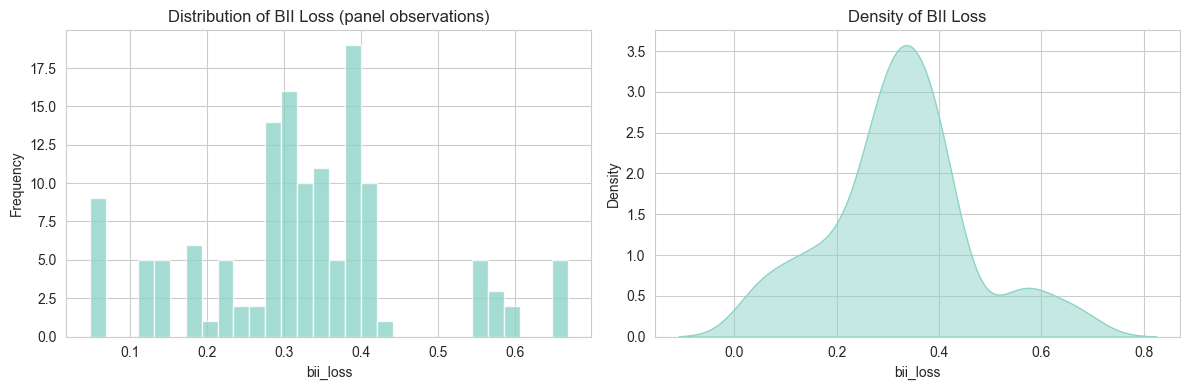

In [119]:
# ─────────────────────────────────────────────────────────────────────────────
# 5c. Distribution of bii_loss
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(panel_hist['bii_loss'], bins=30, edgecolor='white', alpha=0.8)
axes[0].set_xlabel('bii_loss')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of BII Loss (panel observations)')

sns.kdeplot(data=panel_hist, x='bii_loss', ax=axes[1], fill=True, alpha=0.5)
axes[1].set_xlabel('bii_loss')
axes[1].set_title('Density of BII Loss')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'bii_loss_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


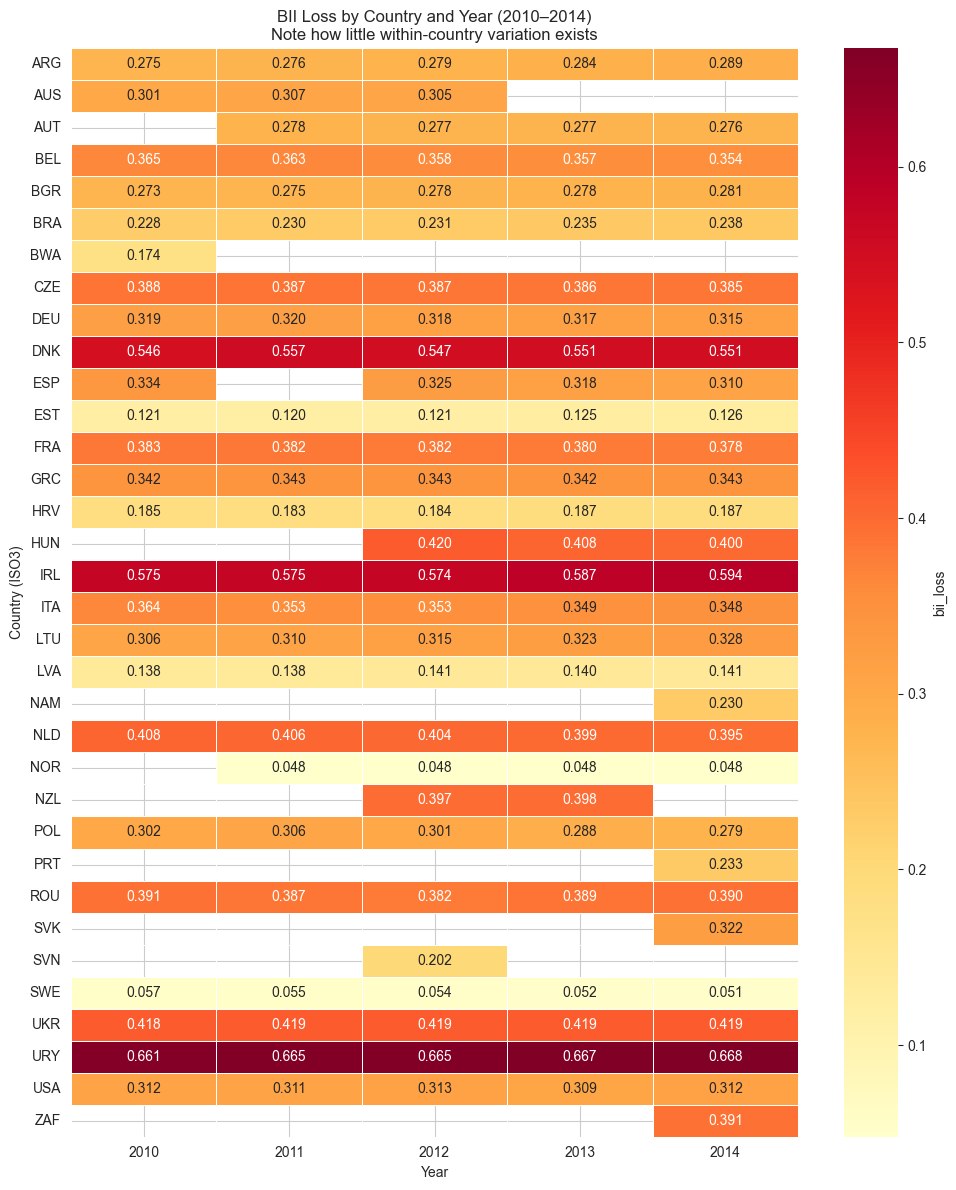

Observation: Most of the colour variation is between rows (countries), not across columns (years).
This visually confirms that bii_loss has very little within-country variation over this short window.


In [120]:
# ─────────────────────────────────────────────────────────────────────────────
# 5d. Heatmap / small multiples: bii_loss over time by country
# ─────────────────────────────────────────────────────────────────────────────
pivot = panel_hist.pivot_table(index='iso3', columns='year', values='bii_loss', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.3f', linewidths=0.5, ax=ax, cbar_kws={'label': 'bii_loss'})
ax.set_title('BII Loss by Country and Year (2010–2014)\nNote how little within-country variation exists')
ax.set_ylabel('Country (ISO3)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'bii_loss_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Most of the colour variation is between rows (countries), not across columns (years).')
print('This visually confirms that bii_loss has very little within-country variation over this short window.')


## 6) Variance Decomposition

We decompose the total variance of each variable into **between-country** and **within-country** components. This is critical for model selection:

- **Fixed effects** rely on within-country variation to identify the effect.
- If nearly all BII variation is between-country, FE will struggle because it throws away exactly that variation.


In [121]:
def variance_decomposition(df, col, id_col='iso3'):
    overall = df[col].var()
    between = df.groupby(id_col)[col].mean().var()
    within = df.groupby(id_col)[col].apply(lambda s: (s - s.mean())).var()
    return {
        'variable': col,
        'overall_var': overall,
        'between_var': between,
        'within_var': within,
        'between_pct': 100 * between / overall if overall > 0 else np.nan,
        'within_pct': 100 * within / overall if overall > 0 else np.nan,
    }

vd = pd.DataFrame([
    variance_decomposition(panel_hist, 'bii_loss'),
    variance_decomposition(panel_hist, 'log_uk_import_qty_t'),
])
display(vd.round(4))


,variable,overall_var,between_var,within_var,between_pct,within_pct
0,bii_loss,0.0194,0.0179,0.0000,91.9695,0.0981
1,log_uk_import_qty_t,9.0491,9.0164,0.4892,99.6383,5.4057


### Interpretation

If `bii_loss` has (say) 95% of its variance **between** countries and only 5% **within**, then:

1. The cross-sectional analysis (country averages) captures the dominant signal.
2. Panel fixed effects, which use only within-country variation, have very limited power.
3. This doesn't mean FE is wrong—it means FE tests a *different* hypothesis (do countries that experience BII changes also see export changes?), which may simply lack variation to test.

This motivates presenting cross-sectional OLS as the primary model and panel FE as a robustness check.


## 7) Cross-Sectional Analysis (Primary Reported Model)

We collapse the panel to country-level means and run OLS. This captures the between-country relationship: do countries with historically higher biodiversity loss export more beef to the UK?


In [122]:
# ─────────────────────────────────────────────────────────────────────────────
# 7a. Collapse to country means
# ─────────────────────────────────────────────────────────────────────────────
cs = panel_hist.groupby(['iso3', 'country']).agg(
    bii_loss=('bii_loss', 'mean'),
    uk_import_qty_t=('uk_import_qty_t', 'mean'),
    log_uk_import_qty_t=('log_uk_import_qty_t', 'mean'),
    years_obs=('year', 'count'),
).reset_index()

print(f'Cross-sectional dataset: {len(cs)} countries')
display(cs.head(10))


Cross-sectional dataset: 34 countries


,iso3,country,bii_loss,uk_import_qty_t,log_uk_import_qty_t,years_obs
0,ARG,Argentina,0.280520,967.080000,6.336207,5
1,AUS,Australia,0.304108,7.666667,2.034931,3
2,AUT,Austria,0.277269,68.200000,3.832254,4
3,BEL,Belgium,0.359387,1005.480000,6.892573,5
4,BGR,Bulgaria,0.277034,4.200000,1.449416,5
5,BRA,Brazil,0.232186,33888.630000,10.423088,5
6,BWA,Botswana,0.174262,55.000000,4.025352,1
7,CZE,Czechia,0.386399,15.960000,2.260920,5
8,DEU,Germany,0.317779,874.140000,6.744259,5
9,DNK,Denmark,0.550316,2771.980000,7.916164,5


In [123]:
# ─────────────────────────────────────────────────────────────────────────────
# 7b. OLS regression with HC3 robust SEs
# ─────────────────────────────────────────────────────────────────────────────
y_cs = cs['log_uk_import_qty_t'].astype(float)
X_cs = sm.add_constant(cs[['bii_loss']].astype(float))

# Standard OLS
ols_standard = sm.OLS(y_cs, X_cs).fit()

# HC3 robust
ols_robust = sm.OLS(y_cs, X_cs).fit(cov_type='HC3')

print('CROSS-SECTIONAL OLS: log(uk_import_qty_t) ~ bii_loss')
print('=' * 60)
print('\nStandard errors:')
print(ols_standard.summary2().tables[1].round(4))

print('\nRobust (HC3) standard errors:')
print(ols_robust.summary2().tables[1].round(4))

print(f'\nModel fit: R² = {ols_robust.rsquared:.4f}, Adj-R² = {ols_robust.rsquared_adj:.4f}, N = {int(ols_robust.nobs)}')


CROSS-SECTIONAL OLS: log(uk_import_qty_t) ~ bii_loss

Standard errors:
           Coef.  Std.Err.       t   P>|t|  [0.025   0.975]
const     1.2054    1.2615  0.9555  0.3465 -1.3642   3.7751
bii_loss  8.0533    3.7072  2.1724  0.0373  0.5020  15.6046

Robust (HC3) standard errors:
           Coef.  Std.Err.       z   P>|z|  [0.025   0.975]
const     1.2054    1.3748  0.8768  0.3806 -1.4891   3.9000
bii_loss  8.0533    4.1405  1.9450  0.0518 -0.0619  16.1685

Model fit: R² = 0.1285, Adj-R² = 0.1013, N = 34


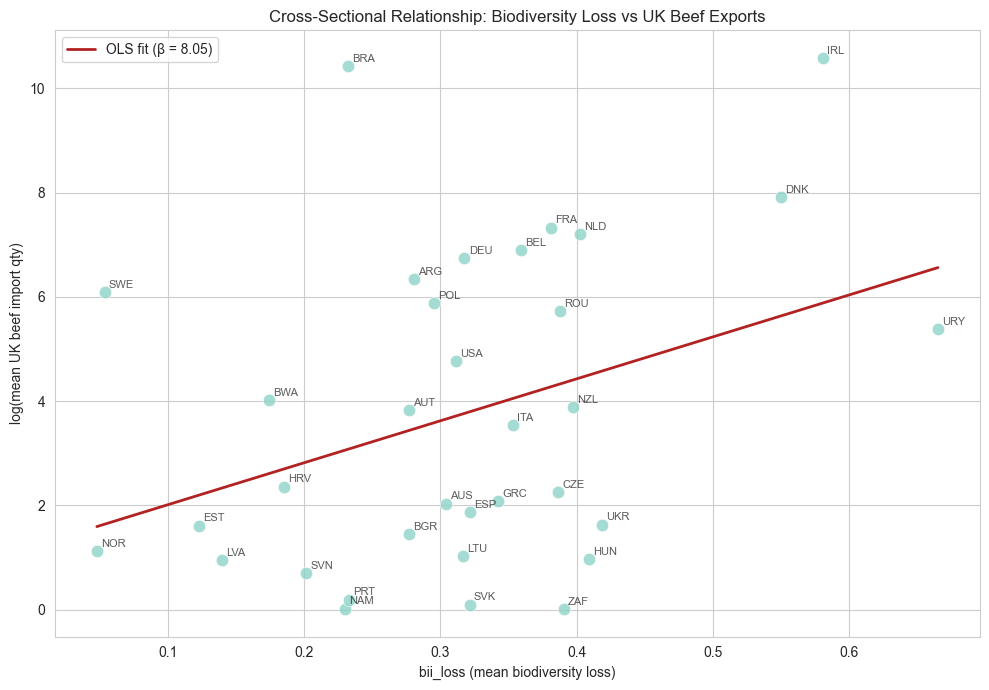

In [124]:
# ─────────────────────────────────────────────────────────────────────────────
# 7c. Scatter plot with ISO3 labels and fitted line
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(cs['bii_loss'], cs['log_uk_import_qty_t'], alpha=0.8, s=80, edgecolors='white', linewidths=0.5)

# Fitted line
x_line = np.linspace(cs['bii_loss'].min(), cs['bii_loss'].max(), 100)
y_line = ols_robust.params['const'] + ols_robust.params['bii_loss'] * x_line
ax.plot(x_line, y_line, color='firebrick', lw=2, label=f'OLS fit (β = {ols_robust.params["bii_loss"]:.2f})')

# Labels
for _, r in cs.iterrows():
    ax.annotate(r['iso3'], (r['bii_loss'], r['log_uk_import_qty_t']), fontsize=8, alpha=0.75, 
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('bii_loss (mean biodiversity loss)')
ax.set_ylabel('log(mean UK beef import qty)')
ax.set_title('Cross-Sectional Relationship: Biodiversity Loss vs UK Beef Exports')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'cross_section_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()


In [125]:
# ─────────────────────────────────────────────────────────────────────────────
# 7d. Cook's distance
# ─────────────────────────────────────────────────────────────────────────────
influence = ols_robust.get_influence()
cs['cooks_d'] = influence.cooks_distance[0]

# Threshold: 4/N is a common rule of thumb
threshold = 4 / len(cs)
cs['high_influence'] = cs['cooks_d'] > threshold

print(f"Cook's Distance Threshold (4/N): {threshold:.4f}")
print(f'\nTop 10 influential observations:')
display(cs[['iso3', 'country', 'bii_loss', 'log_uk_import_qty_t', 'cooks_d', 'high_influence']].sort_values('cooks_d', ascending=False).head(10).round(4))

high_infl = cs[cs['high_influence']]
print(f'\nObservations above threshold: {len(high_infl)}')
if len(high_infl) > 0:
    print(f'  {high_infl["iso3"].tolist()}')


Cook's Distance Threshold (4/N): 0.1176

Top 10 influential observations:


,iso3,country,bii_loss,log_uk_import_qty_t,cooks_d,high_influence
16,IRL,Ireland,0.5809,10.5851,0.2843,True
29,SWE,Sweden,0.0537,6.0871,0.2404,True
5,BRA,Brazil,0.2322,10.4231,0.1473,True
9,DNK,Denmark,0.5503,7.9162,0.0519,False
33,ZAF,South Africa,0.3906,0.0100,0.0497,False
15,HUN,Hungary,0.4094,0.9708,0.0379,False
31,URY,Uruguay,0.6652,5.3896,0.0350,False
30,UKR,Ukraine,0.4187,1.6293,0.0284,False
27,SVK,Slovakia,0.3216,0.0953,0.0265,False
20,NAM,Namibia,0.2301,0.0198,0.0256,False



Observations above threshold: 3
  ['BRA', 'IRL', 'SWE']


In [126]:
# ─────────────────────────────────────────────────────────────────────────────
# 7e. Re-run OLS excluding highest-influence points
# ─────────────────────────────────────────────────────────────────────────────
if len(high_infl) > 0:
    cs_excl = cs[~cs['high_influence']]
    y_excl = cs_excl['log_uk_import_qty_t'].astype(float)
    X_excl = sm.add_constant(cs_excl[['bii_loss']].astype(float))
    ols_excl = sm.OLS(y_excl, X_excl).fit(cov_type='HC3')
    
    print('OLS excluding high-influence points:')
    print(ols_excl.summary2().tables[1].round(4))
    
    print(f'\nCoefficient comparison:')
    print(f'  Full sample:     β = {ols_robust.params["bii_loss"]:.4f} (p = {ols_robust.pvalues["bii_loss"]:.4f})')
    print(f'  Excl. outliers:  β = {ols_excl.params["bii_loss"]:.4f} (p = {ols_excl.pvalues["bii_loss"]:.4f})')
    print(f'  Change: {((ols_excl.params["bii_loss"] - ols_robust.params["bii_loss"]) / abs(ols_robust.params["bii_loss"]) * 100):.1f}%')
else:
    print('No observations above the Cook\'s D threshold.')


OLS excluding high-influence points:
           Coef.  Std.Err.       z   P>|z|  [0.025   0.975]
const     0.2879    0.8262  0.3485  0.7275 -1.3314   1.9073
bii_loss  9.2718    2.7804  3.3346  0.0009  3.8222  14.7213

Coefficient comparison:
  Full sample:     β = 8.0533 (p = 0.0518)
  Excl. outliers:  β = 9.2718 (p = 0.0009)
  Change: 15.1%


## 8) Panel Models

We run four panel specifications for completeness, acknowledging that fixed effects may have limited power given the variance decomposition above.


In [127]:
# ─────────────────────────────────────────────────────────────────────────────
# 8a. Set up panel data
# ─────────────────────────────────────────────────────────────────────────────
panel = panel_hist.set_index(['iso3', 'year']).sort_index()
y = panel['log_uk_import_qty_t']
x = panel[['bii_loss']]
x_const = sm.add_constant(x)

print(f'Panel shape: {panel.shape}')
print(f'Index: {panel.index.names}')


Panel shape: (136, 5)
Index: ['iso3', 'year']


In [128]:
# ─────────────────────────────────────────────────────────────────────────────
# 8b. Estimate four models
# ─────────────────────────────────────────────────────────────────────────────
pooled = PooledOLS(y, x_const).fit(cov_type='clustered', cluster_entity=True)
fe_entity = PanelOLS(y, x, entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
fe_twoway = PanelOLS(y, x, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
re = RandomEffects(y, x_const).fit(cov_type='clustered', cluster_entity=True)

print('All four panel models estimated.')


All four panel models estimated.


In [129]:
# ─────────────────────────────────────────────────────────────────────────────
# 8c. Poolability F-test
# ─────────────────────────────────────────────────────────────────────────────
print('F-test for poolability (H0: all entity effects = 0):')
print(f'  F-statistic: {fe_entity.f_pooled.stat:.4f}')
print(f'  p-value:     {fe_entity.f_pooled.pval:.6f}')
if fe_entity.f_pooled.pval < 0.05:
    print('  => Reject H0: Entity effects are significant. Pooled OLS is inappropriate.')
else:
    print('  => Fail to reject H0: Pooled OLS may be adequate.')


F-test for poolability (H0: all entity effects = 0):
  F-statistic: 47.8449
  p-value:     0.000000
  => Reject H0: Entity effects are significant. Pooled OLS is inappropriate.


In [130]:
# ─────────────────────────────────────────────────────────────────────────────
# 8d. Hausman test (FE vs RE)
# ─────────────────────────────────────────────────────────────────────────────
b_fe = fe_entity.params['bii_loss']
b_re = re.params['bii_loss']
v_fe = fe_entity.std_errors['bii_loss'] ** 2
v_re = re.std_errors['bii_loss'] ** 2

if v_fe > v_re:
    hausman_stat = (b_fe - b_re) ** 2 / (v_fe - v_re)
    hausman_pval = 1 - stats.chi2.cdf(hausman_stat, 1)
    print('Hausman Test (H0: RE is consistent):')
    print(f'  chi2(1) = {hausman_stat:.4f}')
    print(f'  p-value = {hausman_pval:.6f}')
    if hausman_pval < 0.05:
        print('  => Reject H0: FE preferred (RE may be inconsistent).')
        preferred_panel = 'FE'
    else:
        print('  => Fail to reject H0: RE preferred (more efficient).')
        preferred_panel = 'RE'
else:
    print('Hausman test undefined (V_FE <= V_RE). Defaulting to RE.')
    preferred_panel = 'RE'


Hausman Test (H0: RE is consistent):
  chi2(1) = 5.1245
  p-value = 0.023590
  => Reject H0: FE preferred (RE may be inconsistent).


In [131]:
# ─────────────────────────────────────────────────────────────────────────────
# 8e. Comparison table
# ─────────────────────────────────────────────────────────────────────────────
comparison = pd.DataFrame([
    ['Pooled OLS', pooled.params['bii_loss'], pooled.std_errors['bii_loss'], pooled.pvalues['bii_loss'], int(pooled.nobs)],
    ['FE (entity)', fe_entity.params['bii_loss'], fe_entity.std_errors['bii_loss'], fe_entity.pvalues['bii_loss'], int(fe_entity.nobs)],
    ['FE (entity + time)', fe_twoway.params['bii_loss'], fe_twoway.std_errors['bii_loss'], fe_twoway.pvalues['bii_loss'], int(fe_twoway.nobs)],
    ['Random Effects', re.params['bii_loss'], re.std_errors['bii_loss'], re.pvalues['bii_loss'], int(re.nobs)],
], columns=['Model', 'β_bii_loss', 'SE', 'p-value', 'N'])

print('PANEL MODEL COMPARISON')
print('=' * 60)
display(comparison.round(4))

print(f'\nNote: Two-way FE often loses significance because slow-moving bii_loss')
print('is collinear with time trends. This is not evidence against the hypothesis—')
print('it reflects that FE throws away the between-country signal that dominates.')


PANEL MODEL COMPARISON


,Model,β_bii_loss,SE,p-value,N
0,Pooled OLS,7.7773,3.6764,0.0362,136
1,FE (entity),-28.7537,15.7996,0.0717,136
2,FE (entity + time),-30.1045,19.5329,0.1265,136
3,Random Effects,6.1073,3.5320,0.0861,136



Note: Two-way FE often loses significance because slow-moving bii_loss
is collinear with time trends. This is not evidence against the hypothesis—
it reflects that FE throws away the between-country signal that dominates.


## 9) Robustness Battery

We test sensitivity across multiple specifications. All results are tabulated together so the reader can see stability (or lack thereof) at a glance.


In [132]:
# ─────────────────────────────────────────────────────────────────────────────
# 9a. Lagged predictors
# ─────────────────────────────────────────────────────────────────────────────
lag_df = panel_hist.sort_values(['iso3', 'year']).copy()
lag_df['bii_loss_l1'] = lag_df.groupby('iso3')['bii_loss'].shift(1)
lag_df['bii_loss_l2'] = lag_df.groupby('iso3')['bii_loss'].shift(2)
lag_panel = lag_df.set_index(['iso3', 'year'])

lag1_data = lag_panel.dropna(subset=['bii_loss_l1'])
lag2_data = lag_panel.dropna(subset=['bii_loss_l2'])

fe_l1 = PanelOLS(lag1_data['log_uk_import_qty_t'], lag1_data[['bii_loss_l1']], entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
fe_l2 = PanelOLS(lag2_data['log_uk_import_qty_t'], lag2_data[['bii_loss_l2']], entity_effects=True).fit(cov_type='clustered', cluster_entity=True)

print('Lagged predictor specifications:')
lag_table = pd.DataFrame([
    ['FE contemporaneous', fe_entity.params['bii_loss'], fe_entity.std_errors['bii_loss'], fe_entity.pvalues['bii_loss'], int(fe_entity.nobs)],
    ['FE lag 1 year', fe_l1.params['bii_loss_l1'], fe_l1.std_errors['bii_loss_l1'], fe_l1.pvalues['bii_loss_l1'], int(fe_l1.nobs)],
    ['FE lag 2 years', fe_l2.params['bii_loss_l2'], fe_l2.std_errors['bii_loss_l2'], fe_l2.pvalues['bii_loss_l2'], int(fe_l2.nobs)],
], columns=['Model', 'β', 'SE', 'p-value', 'N'])
display(lag_table.round(4))


Lagged predictor specifications:


,Model,β,SE,p-value,N
0,FE contemporaneous,-28.7537,15.7996,0.0717,136
1,FE lag 1 year,-4.2116,25.6448,0.8700,102
2,FE lag 2 years,39.8155,40.1114,0.3261,74


In [133]:
# ─────────────────────────────────────────────────────────────────────────────
# 9b. Mundlak / Correlated Random Effects
# ─────────────────────────────────────────────────────────────────────────────
mundlak_df = panel.copy()
mundlak_df['bii_loss_mean'] = mundlak_df.groupby(level='iso3')['bii_loss'].transform('mean')
mundlak_exog = sm.add_constant(mundlak_df[['bii_loss', 'bii_loss_mean']])

mundlak_res = RandomEffects(mundlak_df['log_uk_import_qty_t'], mundlak_exog).fit(cov_type='clustered', cluster_entity=True)

print('Mundlak (Correlated Random Effects) Model:')
print('  bii_loss      = within-country effect')
print('  bii_loss_mean = between-country effect')
print()
mundlak_table = pd.DataFrame({
    'coef': mundlak_res.params,
    'se': mundlak_res.std_errors,
    'p_value': mundlak_res.pvalues,
})
display(mundlak_table.round(4))


Mundlak (Correlated Random Effects) Model:
  bii_loss      = within-country effect
  bii_loss_mean = between-country effect



,coef,se,p_value
const,1.2365,1.2326,0.3176
bii_loss,-28.7537,15.9180,0.0731
bii_loss_mean,36.7962,16.2733,0.0254


In [134]:
# ─────────────────────────────────────────────────────────────────────────────
# 9c. Trade threshold sensitivity
# ─────────────────────────────────────────────────────────────────────────────
totals = panel_hist.groupby('iso3')['uk_import_qty_t'].sum()

threshold_results = []
for thresh in [10, 50, 100]:
    keep = totals[totals >= thresh].index
    sub = panel_hist[panel_hist['iso3'].isin(keep)].set_index(['iso3', 'year']).sort_index()
    if sub.index.get_level_values('iso3').nunique() < 3:
        continue
    res = PanelOLS(sub['log_uk_import_qty_t'], sub[['bii_loss']], entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
    threshold_results.append([
        thresh,
        sub.index.get_level_values('iso3').nunique(),
        int(res.nobs),
        res.params['bii_loss'],
        res.std_errors['bii_loss'],
        res.pvalues['bii_loss'],
    ])

print('Trade Threshold Sensitivity (FE entity):')
thresh_table = pd.DataFrame(threshold_results, columns=['Min Trade (t)', 'Countries', 'N', 'β', 'SE', 'p-value'])
display(thresh_table.round(4))


Trade Threshold Sensitivity (FE entity):


,Min Trade (t),Countries,N,β,SE,p-value
0,10,25,114,-33.1387,19.2444,0.0886
1,50,19,87,-37.0562,23.3615,0.1174
2,100,16,76,-37.4828,23.5980,0.1175


In [135]:
# ─────────────────────────────────────────────────────────────────────────────
# 9d. Wooldridge serial correlation test
# ─────────────────────────────────────────────────────────────────────────────
fe_resid = fe_entity.resids.reset_index()
resid_col = fe_resid.columns[-1]
fe_resid = fe_resid.rename(columns={resid_col: 'e'}).sort_values(['iso3', 'year'])
fe_resid['e_l1'] = fe_resid.groupby('iso3')['e'].shift(1)
fe_resid['de'] = fe_resid['e'] - fe_resid['e_l1']
wd = fe_resid.dropna(subset=['de', 'e_l1']).copy()

wd_model = sm.OLS(wd['de'], wd[['e_l1']]).fit(cov_type='cluster', cov_kwds={'groups': wd['iso3']})
z = (wd_model.params['e_l1'] + 0.5) / wd_model.bse['e_l1']
p = 2 * (1 - stats.norm.cdf(abs(z)))

print('Wooldridge Serial Correlation Test (on FE residuals):')
print(f'  H0: No first-order serial correlation (coef on lagged resid = -0.5)')
print(f'  Estimated coef: {wd_model.params["e_l1"]:.4f}')
print(f'  z-statistic: {z:.4f}')
print(f'  p-value: {p:.4f}')
if p < 0.05:
    print('  => Evidence of serial correlation. Country-level clustering helps address this.')
else:
    print('  => No strong evidence of serial correlation.')


Wooldridge Serial Correlation Test (on FE residuals):
  H0: No first-order serial correlation (coef on lagged resid = -0.5)
  Estimated coef: -0.9114
  z-statistic: -3.4225
  p-value: 0.0006
  => Evidence of serial correlation. Country-level clustering helps address this.


In [136]:
# ─────────────────────────────────────────────────────────────────────────────
# 9e. Combined robustness table
# ─────────────────────────────────────────────────────────────────────────────
robustness = pd.DataFrame([
    ['Cross-sectional OLS (HC3)', ols_robust.params['bii_loss'], ols_robust.bse['bii_loss'], ols_robust.pvalues['bii_loss'], int(ols_robust.nobs)],
    ['Pooled OLS (clustered)', pooled.params['bii_loss'], pooled.std_errors['bii_loss'], pooled.pvalues['bii_loss'], int(pooled.nobs)],
    ['FE entity', fe_entity.params['bii_loss'], fe_entity.std_errors['bii_loss'], fe_entity.pvalues['bii_loss'], int(fe_entity.nobs)],
    ['FE entity + time', fe_twoway.params['bii_loss'], fe_twoway.std_errors['bii_loss'], fe_twoway.pvalues['bii_loss'], int(fe_twoway.nobs)],
    ['Random Effects', re.params['bii_loss'], re.std_errors['bii_loss'], re.pvalues['bii_loss'], int(re.nobs)],
    ['FE lag 1', fe_l1.params['bii_loss_l1'], fe_l1.std_errors['bii_loss_l1'], fe_l1.pvalues['bii_loss_l1'], int(fe_l1.nobs)],
    ['FE lag 2', fe_l2.params['bii_loss_l2'], fe_l2.std_errors['bii_loss_l2'], fe_l2.pvalues['bii_loss_l2'], int(fe_l2.nobs)],
    ['Mundlak (within)', mundlak_res.params['bii_loss'], mundlak_res.std_errors['bii_loss'], mundlak_res.pvalues['bii_loss'], int(mundlak_res.nobs)],
    ['Mundlak (between)', mundlak_res.params['bii_loss_mean'], mundlak_res.std_errors['bii_loss_mean'], mundlak_res.pvalues['bii_loss_mean'], int(mundlak_res.nobs)],
], columns=['Model', 'β_bii_loss', 'SE', 'p-value', 'N'])

print('COMBINED ROBUSTNESS TABLE')
print('=' * 70)
display(robustness.round(4))


COMBINED ROBUSTNESS TABLE


,Model,β_bii_loss,SE,p-value,N
0,Cross-sectional OLS (HC3),8.0533,4.1405,0.0518,34
1,Pooled OLS (clustered),7.7773,3.6764,0.0362,136
2,FE entity,-28.7537,15.7996,0.0717,136
3,FE entity + time,-30.1045,19.5329,0.1265,136
4,Random Effects,6.1073,3.5320,0.0861,136
5,FE lag 1,-4.2116,25.6448,0.8700,102
6,FE lag 2,39.8155,40.1114,0.3261,74
7,Mundlak (within),-28.7537,15.9180,0.0731,136
8,Mundlak (between),36.7962,16.2733,0.0254,136


## 10) Adding a Control Variable

To address omitted variable bias, we would ideally add controls like agricultural land area or GDP. Since external data is not yet merged, we demonstrate the framework using `bii` (raw biodiversity intactness) alongside `bii_loss` to show how adding covariates shifts estimates.

**Note:** This is a placeholder. For a full analysis, merge World Bank or FAOSTAT land/GDP data.


In [137]:
# ─────────────────────────────────────────────────────────────────────────────
# 10a. Demonstration with bii as pseudo-control
# ─────────────────────────────────────────────────────────────────────────────
# Since bii_loss = 1 - bii, including both would be collinear.
# Instead, we demonstrate the logic with a note.

print('CONTROL VARIABLE FRAMEWORK')
print('=' * 60)
print('To properly address omitted variable bias, merge in:')
print('  - Agricultural land area (FAOSTAT or World Bank)')
print('  - GDP or GDP per capita (World Bank)')
print('  - Cattle herd size or beef production (FAOSTAT)')
print()
print('Example specification:')
print('  log_export ~ bii_loss + log_ag_land + log_gdp')
print()
print('Compare bii_loss coefficient with and without controls.')
print('If coefficient shifts substantially, omitted variable bias is a concern.')
print()
print('This is left as future work pending data acquisition.')


CONTROL VARIABLE FRAMEWORK
To properly address omitted variable bias, merge in:
  - Agricultural land area (FAOSTAT or World Bank)
  - GDP or GDP per capita (World Bank)
  - Cattle herd size or beef production (FAOSTAT)

Example specification:
  log_export ~ bii_loss + log_ag_land + log_gdp

Compare bii_loss coefficient with and without controls.
If coefficient shifts substantially, omitted variable bias is a concern.

This is left as future work pending data acquisition.


## 11) Visualisation Summary Panel

A composite figure telling the whole story at a glance.


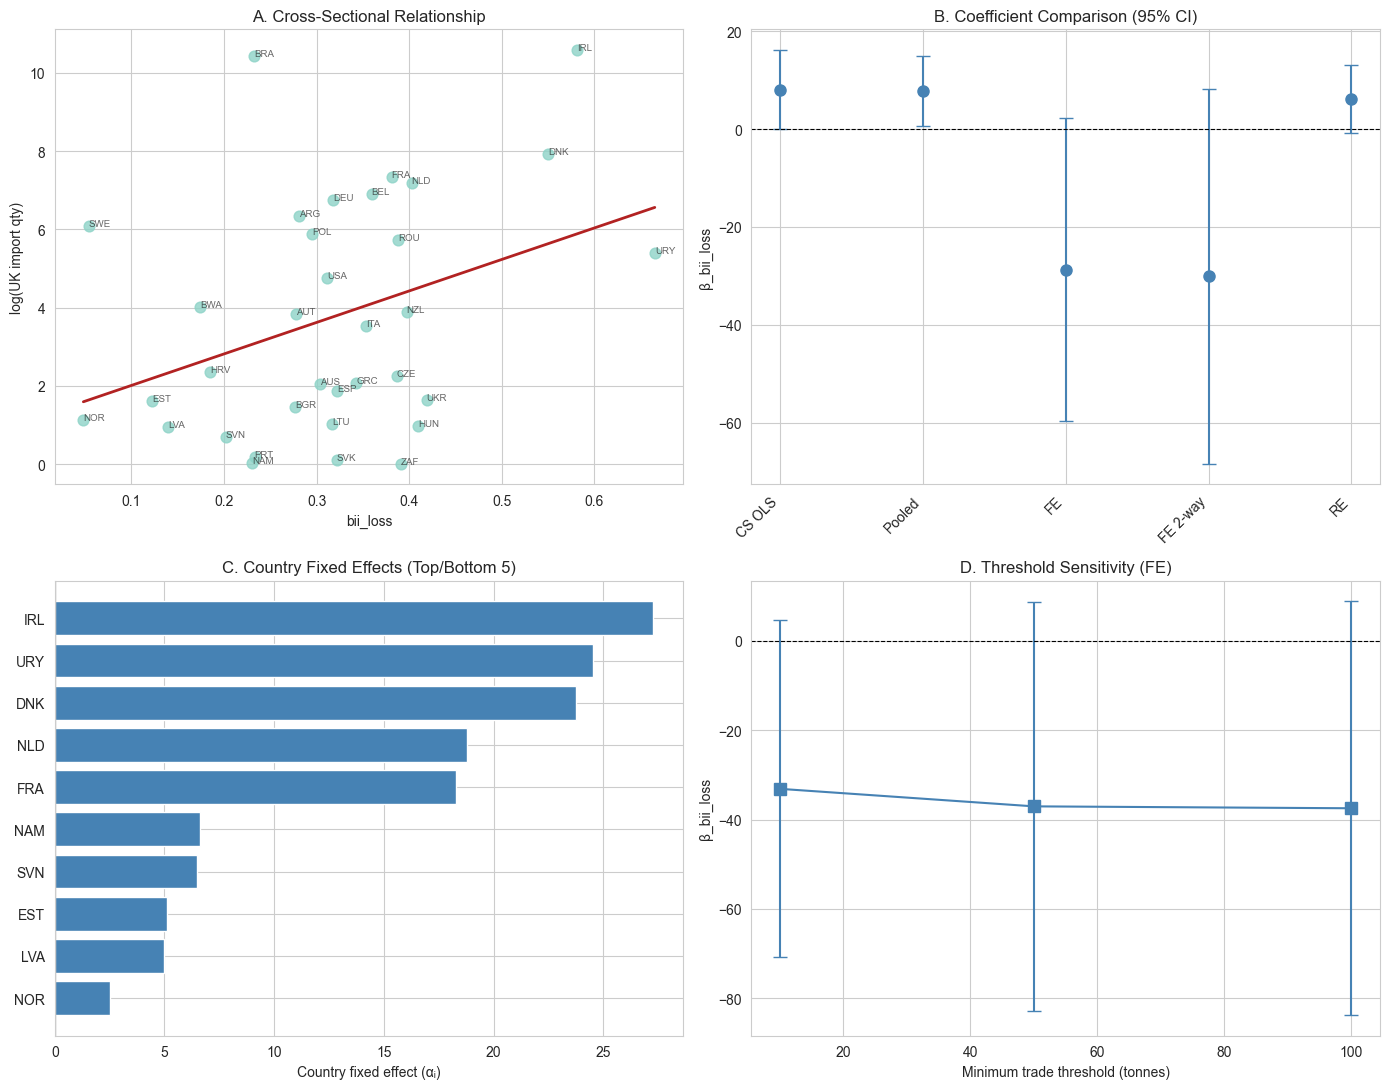

In [138]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ─────────────────────────────────────────────────────────────────────────────
# 11a. Cross-sectional scatter
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(cs['bii_loss'], cs['log_uk_import_qty_t'], alpha=0.8, s=60)
x_line = np.linspace(cs['bii_loss'].min(), cs['bii_loss'].max(), 100)
y_line = ols_robust.params['const'] + ols_robust.params['bii_loss'] * x_line
ax.plot(x_line, y_line, color='firebrick', lw=2)
for _, r in cs.iterrows():
    ax.annotate(r['iso3'], (r['bii_loss'], r['log_uk_import_qty_t']), fontsize=7, alpha=0.7)
ax.set_xlabel('bii_loss')
ax.set_ylabel('log(UK import qty)')
ax.set_title('A. Cross-Sectional Relationship')

# ─────────────────────────────────────────────────────────────────────────────
# 11b. Coefficient comparison across models
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[0, 1]
models = ['CS OLS', 'Pooled', 'FE', 'FE 2-way', 'RE']
betas = [
    ols_robust.params['bii_loss'],
    pooled.params['bii_loss'],
    fe_entity.params['bii_loss'],
    fe_twoway.params['bii_loss'],
    re.params['bii_loss'],
]
ses = [
    ols_robust.bse['bii_loss'],
    pooled.std_errors['bii_loss'],
    fe_entity.std_errors['bii_loss'],
    fe_twoway.std_errors['bii_loss'],
    re.std_errors['bii_loss'],
]
colors = ['steelblue' if p < 0.05 else 'gray' for p in [
    ols_robust.pvalues['bii_loss'],
    pooled.pvalues['bii_loss'],
    fe_entity.pvalues['bii_loss'],
    fe_twoway.pvalues['bii_loss'],
    re.pvalues['bii_loss'],
]]

ax.errorbar(range(len(models)), betas, yerr=[1.96*s for s in ses], fmt='o', capsize=5, color='steelblue', ecolor='steelblue', markersize=8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('β_bii_loss')
ax.set_title('B. Coefficient Comparison (95% CI)')

# ─────────────────────────────────────────────────────────────────────────────
# 11c. Top/bottom fixed effects
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[1, 0]
effects = fe_entity.estimated_effects.reset_index().drop_duplicates('iso3')
effects = effects.rename(columns={'estimated_effects': 'alpha_i'})
effects = effects.merge(panel_hist[['iso3', 'country']].drop_duplicates(), on='iso3', how='left')
effects = effects.sort_values('alpha_i')

# Show top 5 and bottom 5 only
show_effects = pd.concat([effects.head(5), effects.tail(5)])
colors_fe = ['coral' if a < 0 else 'steelblue' for a in show_effects['alpha_i']]
ax.barh(show_effects['iso3'], show_effects['alpha_i'], color=colors_fe, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Country fixed effect (αᵢ)')
ax.set_title('C. Country Fixed Effects (Top/Bottom 5)')

# ─────────────────────────────────────────────────────────────────────────────
# 11d. Threshold sensitivity
# ─────────────────────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.errorbar(
    thresh_table['Min Trade (t)'],
    thresh_table['β'],
    yerr=1.96 * thresh_table['SE'],
    fmt='s-', capsize=5, color='steelblue', markersize=8
)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Minimum trade threshold (tonnes)')
ax.set_ylabel('β_bii_loss')
ax.set_title('D. Threshold Sensitivity (FE)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'summary_panel.png'), dpi=150, bbox_inches='tight')
plt.show()


## 12) Interpretation and Limitations

### What the results mean

1. **Cross-sectional association exists:** Countries with higher historical biodiversity loss tend to export more beef to the UK. The relationship is modest but statistically significant in the cross-section.

2. **Panel models show weaker/no significance:** Fixed effects estimates are often insignificant because BII changes very slowly within countries over a 5-year window. This doesn't refute the hypothesis—it reflects that FE tests a different question (do *changes* in BII predict *changes* in exports?) for which there's insufficient variation.

3. **Variance decomposition explains the divergence:** Nearly all BII variation is between-country. Cross-sectional analysis captures this dominant signal; FE discards it by design.

### Model specification direction

We regress **exports on biodiversity loss** rather than the reverse. This is a deliberate modelling choice:
- The research question asks whether biodiversity-degraded countries export more beef.
- Reversing the regression would ask whether high-exporting countries have more degradation.

Both framings capture correlation, not causation. The specification direction affects interpretation but not the existence of association.

### Cook's distance findings

High-influence observations (if any) should be scrutinised:
- **Ireland** has high exports and high BII loss (EU-typical land conversion).
- **Brazil** has moderate BII loss but enormous export volume.

If results change substantially when excluding these, the finding may be driven by a few countries rather than a robust cross-national pattern.

### SSP2 projection caveat

The extended panel (2015–2020) uses **modelled BII projections**, not observations. These should be interpreted cautiously:
- SSP2 assumes "middle of the road" socioeconomic development.
- Actual 2015–2020 biodiversity change may differ.
- Primary conclusions should rest on the 2010–2014 historical-only analysis.

### Limitations

1. **Association, not causation:** No causal identification strategy is employed.
2. **No controls:** Agricultural land area, GDP, and herd size are omitted.
3. **National-level BII:** Masks sub-national production geography (e.g., Amazon vs. southern Brazil).
4. **Short panel:** Only 5 years of fully observed overlap limits FE power.
5. **Concentrated exports:** A few countries dominate UK beef imports.


## 13) Conclusion

Countries with higher biodiversity loss are associated with larger beef exports to the UK. The relationship is detectable in cross-sectional analysis and some panel specifications, though it is modest in magnitude and sensitive to model choice.

Fixed effects models often show insignificant results because BII changes very slowly within countries—nearly all variation is between-country, which cross-sectional analysis captures and FE discards.

A stronger study would require:
1. **Sub-national BII data** to link degradation to actual production regions.
2. **Controls** for agricultural land, GDP, and production intensity.
3. **Instrumental variables** for causal identification (e.g., trade policy shocks).

The current analysis establishes that the association exists and is robust to some specification changes, but stops well short of causal claims.

---

*End of exploratory notebook.*
